In [3]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

In [4]:
import pandas as pd
df = pd.read_csv("../../results/reports/features.csv")
df.head()

,img_id,patient_id,lesion_id,gender,skin_cancer_diagnosis,diagnostic,biopsed,mask_components,melanoma_color_count,melanoma_colors,...,convexity_score,lesion_red_share,lesion_green_share,lesion_blue_share,lesion_skin_red_diff,lesion_skin_green_diff,lesion_skin_blue_diff,lesion_skin_rgb_distance,predicted_label,predicted_probability_cancer
0,PAT_684_1303_368.png,PAT_684,1303,MALE,1,BCC,True,2,1,blue_gray,...,0.966073,0.385627,0.316149,0.298224,-4.110664,-4.335522,-3.519299,6.933958,1,0.631991
1,PAT_842_1606_971.png,PAT_842,1606,FEMALE,1,BCC,True,3,1,blue_gray,...,0.968111,0.347777,0.307446,0.344777,-8.710226,-22.357424,-8.463104,25.443006,1,0.742272
2,PAT_113_172_610.png,PAT_113,172,MALE,1,SCC,True,2,2,"red, blue_gray",...,0.982251,0.446228,0.283676,0.270096,7.774562,-7.024822,-2.797506,10.845182,1,0.898004
3,PAT_1633_2855_460.png,PAT_1633,2855,NaN,0,ACK,False,5,0,NaN,...,0.981541,0.425111,0.309371,0.265518,16.566090,18.314028,26.037217,35.885591,0,0.231925
4,PAT_168_262_74.png,PAT_168,262,MALE,1,BCC,True,1,1,blue_gray,...,0.964321,0.417867,0.292136,0.289997,-12.708808,-19.862190,-18.049245,29.695044,1,0.817363


In [5]:
X = df[['lesion_green_share', 'saturation_variance', 'melanoma_color_count',
       'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score',
       'convexity_score', 'lesion_red_share', 'lesion_skin_green_diff',
       'Polsby-Popper']]
y = df['skin_cancer_diagnosis']

In [6]:
patient_labels = df.groupby("patient_id")["skin_cancer_diagnosis"].max()

patients = patient_labels.index
labels = patient_labels.values

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


train_mask = df["patient_id"].isin(train_patients)
test_mask = df["patient_id"].isin(test_patients)


X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [7]:
groups_train = df.loc[X_train.index, "patient_id"]

depths = range(1, 9)

train_accs = []
val_accs = []

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for d in depths:

    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train, groups_train):

        X_tr = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        model = DecisionTreeClassifier(max_depth=d, random_state=1907)
        model.fit(X_tr, y_tr)

        train_acc = model.score(X_tr, y_tr)
        val_acc = model.score(X_val_fold, y_val_fold)

        train_scores.append(train_acc)
        val_scores.append(val_acc)

    # Average across folds
    train_accs.append(np.mean(train_scores))
    val_accs.append(np.mean(val_scores))

    print(f"max_depth = {d} - Train accuracy: {train_accs[-1]:.4f} - Val accuracy: {val_accs[-1]:.4f}")

max_depth = 1 - Train accuracy: 0.6760 - Val accuracy: 0.6699
max_depth = 2 - Train accuracy: 0.7001 - Val accuracy: 0.6830
max_depth = 3 - Train accuracy: 0.7156 - Val accuracy: 0.6872
max_depth = 4 - Train accuracy: 0.7263 - Val accuracy: 0.6791
max_depth = 5 - Train accuracy: 0.7581 - Val accuracy: 0.6813
max_depth = 6 - Train accuracy: 0.7898 - Val accuracy: 0.6885
max_depth = 7 - Train accuracy: 0.8195 - Val accuracy: 0.6805
max_depth = 8 - Train accuracy: 0.8501 - Val accuracy: 0.6709


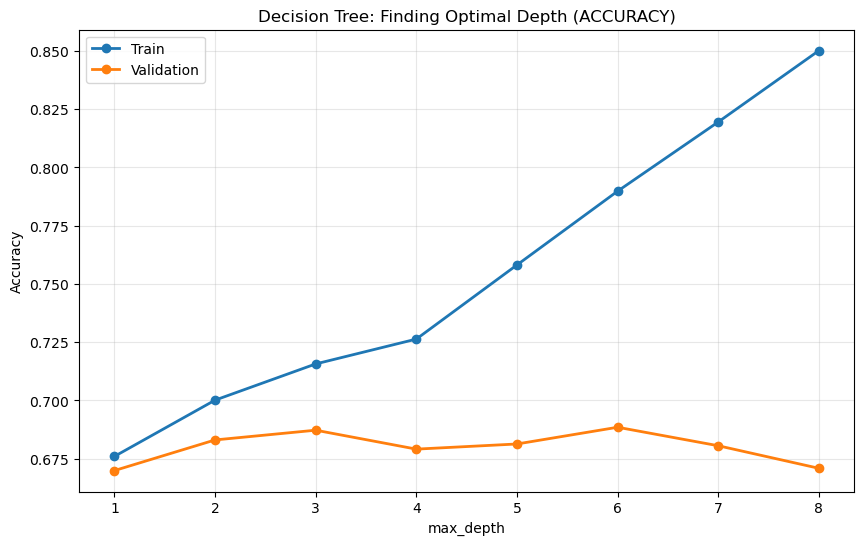

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_accs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_accs, marker='o', label='Validation', linewidth=2)
plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Decision Tree: Finding Optimal Depth (ACCURACY)')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
groups_train = df.loc[X_train.index, "patient_id"]

depths = range(1, 9)

train_aucs = []
val_aucs = []

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for d in depths:

    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train, groups_train):

        X_tr = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        model = DecisionTreeClassifier(max_depth=d, random_state=1907)
        model.fit(X_tr, y_tr)

        # Train AUC
        y_tr_proba = model.predict_proba(X_tr)[:, 1]
        train_auc = roc_auc_score(y_tr, y_tr_proba)
        train_scores.append(train_auc)

        # Validation AUC
        y_val_proba = model.predict_proba(X_val_fold)[:, 1]
        val_auc = roc_auc_score(y_val_fold, y_val_proba)
        val_scores.append(val_auc)

    # Average across folds
    train_aucs.append(np.mean(train_scores))
    val_aucs.append(np.mean(val_scores))

    print(f"max_depth = {d} - Train AUC: {train_aucs[-1]:.4f} - Val AUC: {val_aucs[-1]:.4f}")


max_depth = 1 - Train AUC: 0.6762 - Val AUC: 0.6694
max_depth = 2 - Train AUC: 0.7341 - Val AUC: 0.7157
max_depth = 3 - Train AUC: 0.7650 - Val AUC: 0.7249
max_depth = 4 - Train AUC: 0.7956 - Val AUC: 0.7277
max_depth = 5 - Train AUC: 0.8295 - Val AUC: 0.7305
max_depth = 6 - Train AUC: 0.8635 - Val AUC: 0.7316
max_depth = 7 - Train AUC: 0.9001 - Val AUC: 0.7112
max_depth = 8 - Train AUC: 0.9301 - Val AUC: 0.6923


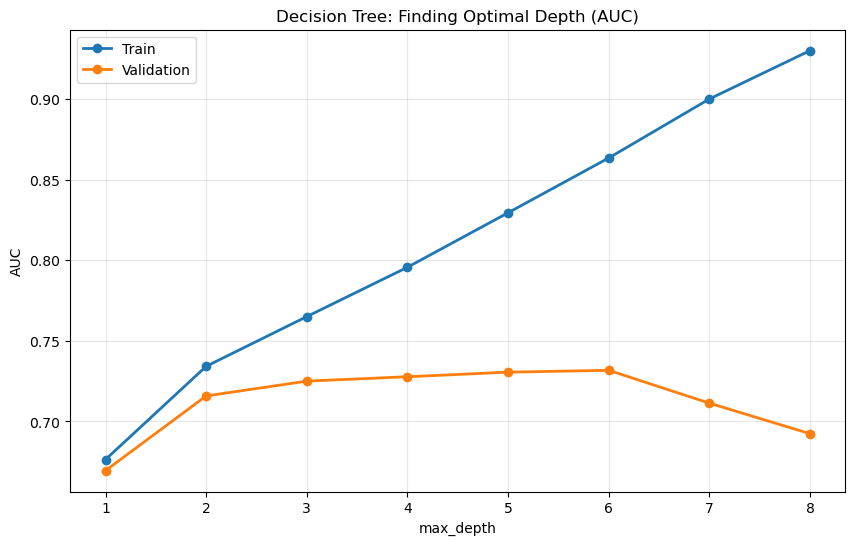

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_aucs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_aucs, marker='o', label='Validation', linewidth=2)

plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Decision Tree: Finding Optimal Depth (AUC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

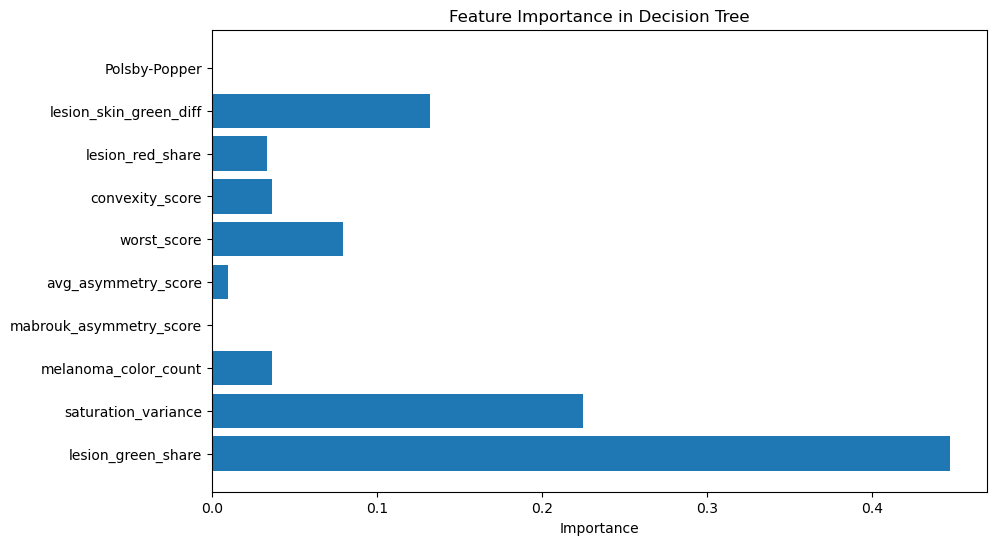

In [11]:
# Train your best model
dt = DecisionTreeClassifier(max_depth=5, random_state=1907)
dt.fit(X_train, y_train)

# See which features are most important
feature_names = ['lesion_green_share', 'saturation_variance', 'melanoma_color_count',
       'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score',
       'convexity_score', 'lesion_red_share', 'lesion_skin_green_diff',
       'Polsby-Popper']

plt.figure(figsize=(10, 6))
plt.barh(feature_names, dt.feature_importances_)
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.show()

In [19]:
import numpy as np

best_idx = np.argmax(val_aucs)

print("Best max_depth:", depths[best_idx])
print("Best ROC AUC:", val_aucs[best_idx])
print("Accuracy at best ROC AUC:", val_accs[best_idx])

Best max_depth: 6
Best ROC AUC: 0.731639838466476
Accuracy at best ROC AUC: 0.6884744727099271
